# SN 2018ivc Late-Time SED: Spectral-Index Shallowing (JWST proposal figure)

Overlays data + best-fit SSA model curve for four VLA epochs (1700, 2100, 2500,
2650 days post-explosion) on one panel, colored by the project's canonical
epoch viridis mapping (`CLAUDE_plotting.md`). 1700 and 2100 days use the
existing fixed-p=3.24 model from `model_params/` (`chi2_comp.py`, per
`sed_fit_commands.txt`); 2500 and 2650 days use a free-p single-component fit
computed in this notebook (2026-09-10 investigation) instead of that epoch's
fixed-p=1.8 model_params/ result, since the free fit is well-behaved
(non-bounds-pegged) and gives a more defensible alpha ~ 0.55-0.57 there. See
`CLAUDE_radio_SOP.md` for the full reasoning, including why 2100 keeps its
fixed-p value (its free fit is bounds-pegged and underconstrained). Inset
shows fitted alpha vs. phase across all four epochs -- shallowing is
1.12 -> 1.12 -> 0.57 -> 0.55.

`build_sed_figure()` produces two renderings: the standard paper-style sizing
(`figures/sed_spectral_shallowing.png/.pdf`) and a larger-font "proposal"
variant (`figures/sed_spectral_shallowing_proposal.png/.pdf`, `scale=1.45`
via `functions.set_plot_style`) for the JWST proposal, where the default
sizes read too small at typical embed sizes.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import functions

functions.set_plot_style()

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

data = pd.read_csv("../data/radio_18ivc_data.csv")

# Four late-time canonical epochs. Phase windows match the actual chi2_comp.py
# fit windows in sed_fit_commands.txt (not the wider bins in CLAUDE_plotting.md's
# epoch table), so the data points plotted here are exactly the ones that went
# into each fit.
#
# Methodology is deliberately mixed across epochs (2026-09-10 decision, see
# CLAUDE_radio_SOP.md): 1700 and 2100 days use the existing fixed-p=3.24
# best-fit-selected model from model_params/ (chi2_comp.py, per
# sed_fit_commands.txt). 2500 and 2650 days use a *free*-p single-component fit
# instead of the model_params/ fixed-p=1.8 result -- a free-p sanity check
# (2026-09-10 investigation) showed both epochs independently converge, from a
# well-behaved, non-bounds-pegged fit, on alpha ~ 0.55-0.57, distinctly shallow
# but different from the fixed-p=1.8 assumption's alpha=0.4. 2100's free-p fit
# is not usable this way: a single component doesn't fit at all, and the free
# 2-component fit pegs both p's at the imposed upper bound (5.0) with only 8
# data points and 6 free parameters (dof=2) -- underconstrained, not a
# trustworthy number -- so 2100 (and 1700, never re-fit free) keep their
# original fixed-p values.
EPOCHS = [
    (1700.0, 1600, 1800, "fixed", "../model_params/best_fit_params_1700.0_days.csv"),
    (2100.0, 2000, 2200, "fixed", "../model_params/best_fit_params_2100.0_days.csv"),
    (2500.0, 2400, 2600, "free", dict(comp1_guess=[15.0, 3.0, 1.8], nu1last=4.25, amp_lower=1.0)),
    (2650.0, 2600, 2700, "free", dict(comp1_guess=[18.0, 3.0, 1.8], nu1last=3.46, amp_lower=1.0)),
]

# Canonical viridis x-position per epoch, per CLAUDE_plotting.md's 11-epoch
# project-wide list (radio + X-ray interleaved). Hardcoded, not a local
# linspace over just these 4 epochs -- see the "known inconsistency" note in
# CLAUDE_plotting.md for why that matters.
CANONICAL_X = {1700.0: 0.500, 2100.0: 0.300, 2500.0: 0.200, 2650.0: 0.000}
cmap = mpl.colormaps["viridis"]

In [2]:
# --- Compute each epoch's data subset, best-fit curve, and alpha (no plotting
# here -- kept separate from figure-building so the fits/free-p CSV writes
# happen exactly once, regardless of how many font-size variants get built
# from build_sed_figure() below). ---
freq_range = np.logspace(np.log10(1.0), np.log10(45.0), 400)

# (label, avg_phase, d_epoch, best_fit_curve, alpha, color, edge_color, curve_color, is_free)
epoch_plot_data = []
curve_min, curve_max = np.inf, -np.inf

for label, lo, hi, method, spec in EPOCHS:
    color = cmap(CANONICAL_X[label])
    edge_color = darken_color(color, 0.7)
    curve_color = darken_color(color, 0.55)

    d_epoch = data[(data["phase"] >= lo) & (data["phase"] <= hi)]
    avg_phase = d_epoch["phase"].mean()

    if method == "fixed":
        params = pd.read_csv(spec, index_col=0)
    else:
        # Free-p single-component fit (2026-09-10 investigation): re-run here
        # (not just pasted numbers) so the notebook is self-contained and
        # reproducible. Matches functions.one_comp_ls_fit's bounds (p in
        # [1.5, 5.0]) -- see CLAUDE_radio_SOP.md for why the 2-component free
        # fit isn't used instead (bounds-pegged, underconstrained at only 8
        # points / 6 free params).
        best_fit_params, red_chi2 = functions.one_comp_ls_fit(
            data, lo, hi, 1.21, 40.0, spec["comp1_guess"], spec["nu1last"],
            amp_lower=spec["amp_lower"], plot=False, chi2=True, fix_p=None,
        )
        F_p, nu_p, p = best_fit_params
        params = pd.DataFrame(
            {"F_p (mJy)": [F_p], "nu_p (GHz)": [nu_p], "p": [p], "alpha": [(p - 1) / 2]},
            index=["Component 1 (free p)"],
        )
        # Persist alongside the fixed-p model_params/ files, under a distinct
        # name -- does NOT overwrite best_fit_params_<phase>_days.csv, which
        # stays the chi2_comp.py/sed_fit_commands.txt fixed-p record.
        params.to_csv(f"../model_params/best_fit_params_{label}_days_freep.csv")

    p_vals = params["p"].values
    assert np.allclose(p_vals, p_vals[0]), (
        f"epoch {label}: components have different p ({p_vals}) -- "
        "alpha is ambiguous, update this cell before trusting the inset"
    )
    alpha = params["alpha"].iloc[0]

    if len(params) == 1:
        F_p, nu_p, p = params.iloc[0][["F_p (mJy)", "nu_p (GHz)", "p"]]
        best_fit = functions.F_SSA_Nayana(freq_range, F_p, nu_p, p)
    elif len(params) == 2:
        (F_p1, nu_p1, p1), (F_p2, nu_p2, p2) = params[["F_p (mJy)", "nu_p (GHz)", "p"]].values
        best_fit = functions.F_SSA_Nayana_2comp(freq_range, F_p1, nu_p1, p1, F_p2, nu_p2, p2)
    else:
        raise ValueError(f"unexpected component count for epoch {label}: {len(params)}")

    curve_min = min(curve_min, np.nanmin(best_fit[best_fit > 0]))
    curve_max = max(curve_max, np.nanmax(best_fit))

    epoch_plot_data.append((label, avg_phase, d_epoch, best_fit, alpha, color, edge_color, curve_color, method == "free"))

# Axes tightened to the four plotted epochs only (not the full project
# dataset, which spans much fainter/brighter epochs never shown on this
# panel) -- requested 2026-09-14 so the optically-thin-slope (spectral-index)
# differences between epochs are easier to read off, instead of being
# compressed by several extra decades of vertical headroom below the data.
#
# xlim: padded around the plotted epochs' actual frequency coverage
# (1.52-33 GHz), rather than the previous fixed (1.0, 45).
epoch_freq = pd.concat([r[2]["freq"] for r in epoch_plot_data])
xlim = (0.85 * epoch_freq.min(), 1.2 * epoch_freq.max())

# ylim: padded around {model curves, data} restricted to xlim -- not the
# curves' full 1-45 GHz evaluation range, whose low-frequency (optically
# thick) plunge toward ~0.1 mJy is well outside where any epoch has data and
# was the main source of the wasted vertical space. Still curve-inclusive
# (not just data-inclusive) within xlim so each epoch's rise and the
# double-peaked 2100-day trough stay visible, matching the original intent.
in_xlim = (freq_range >= xlim[0]) & (freq_range <= xlim[1])
curve_min = min(np.nanmin(r[3][in_xlim][r[3][in_xlim] > 0]) for r in epoch_plot_data)
curve_max = max(np.nanmax(r[3][in_xlim]) for r in epoch_plot_data)

epoch_flux = pd.concat([r[2]["flux"] for r in epoch_plot_data])
epoch_flux_err_low = pd.concat(
    [(r[2]["flux"] - r[2]["flux_err"]).clip(lower=0.01) for r in epoch_plot_data]
)
data_min = epoch_flux_err_low.min()
data_max = epoch_flux.max()

ylim = (0.85 * min(curve_min, data_min), 1.2 * max(curve_max, data_max))

def y_to_axfrac(y):
    return (np.log10(y) - np.log10(ylim[0])) / (np.log10(ylim[1]) - np.log10(ylim[0]))

Single component best fit parameters: [15.84684544  2.9980836   2.14771883]
Chi-squared: 3.77, Reduced Chi-squared: 0.63
Single component best fit parameters: [16.01218532  2.17731058  2.10414338]
Chi-squared: 1.28, Reduced Chi-squared: 0.26


In [3]:
def build_sed_figure(scale=1.0, suffix=""):
    """Build and save one rendering of the SED figure.

    scale: passed to functions.set_plot_style() -- 1.0 for the standard
    (paper-style) sizes, larger (e.g. 1.45) for a "proposal" rendering with
    bigger text. Explicit fontsize= kwargs below (inset labels/ticks, which
    aren't covered by set_plot_style's rcParams) are scaled by hand to match.
    suffix: appended to the saved filename, e.g. "_proposal".
    """
    functions.set_plot_style(scale=scale)
    fig, ax = plt.subplots(figsize=(8, 6.5), dpi=300)

    for label, avg_phase, d_epoch, best_fit, alpha, color, edge_color, curve_color, is_free in epoch_plot_data:
        # Data points -- star marker, matching sed_epoch_grid.ipynb's "this
        # work" convention (all 5 late canonical epochs are this project's
        # own VLA monitoring, so no telescope-based marker splitting needed).
        ax.errorbar(
            d_epoch["freq"], d_epoch["flux"], yerr=d_epoch["flux_err"],
            fmt="*", ms=15, capsize=3, elinewidth=1.5, linestyle="none",
            color=color, markeredgecolor=edge_color, alpha=0.9, zorder=3,
            label=f"{avg_phase:.0f} days",
        )
        # Best-fit curve, in a darkened shade of the same epoch color.
        ax.plot(freq_range, best_fit, color=curve_color, lw=2.5, zorder=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Frequency [GHz]")
    ax.set_ylabel("Flux Density [mJy]")

    # Explicit tick values/labels: the default log locator only draws one
    # major tick (10) over this narrow (~1.6 decade) range, which is
    # unreadable.
    xticks = [2, 3, 5, 10, 20, 40]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_xticks([], minor=True)

    legend = ax.legend(title="Days Post Explosion", loc="lower right", frameon=True)
    legend.get_frame().set_alpha(1.0)
    legend.set_zorder(6)

    # --- Inset: fitted spectral index alpha vs. phase, same epoch colors ---
    # Repositioned 2026-09-10 (previous x0=0.13 clipped the 1700-day epoch's
    # curve on its rising edge -- user-reported). Found by a numeric sliding-
    # window search over the "ceiling" (lowest curve/data value at each x)
    # across all 4 epochs, not eyeballed -- see CLAUDE_radio_SOP.md.
    #
    # Width narrowed to 0.26 (from an initial 0.34) after adding the
    # font-scale option: legend text/title scale with `scale` too, so at
    # scale=1.45 the legend box grows enough to overlap a wider inset's right
    # edge -- this narrower width clears the legend at both scale=1.0 and
    # scale=1.45 (checked by rendering both, not assumed).
    inset_x0, inset_width = 0.27, 0.26
    inset_y0 = 0.16
    inset_height = min(0.36, 0.9 * y_to_axfrac(7.0) - inset_y0)

    axins = ax.inset_axes([inset_x0, inset_y0, inset_width, inset_height])
    axins.set_zorder(10)
    axins.patch.set_facecolor("white")
    axins.patch.set_alpha(1.0)  # fully opaque -- avoid the main SED curves bleeding through

    phases = [r[1] for r in epoch_plot_data]
    alphas = [r[4] for r in epoch_plot_data]
    axins.plot(phases, alphas, color="0.5", lw=1.2, zorder=1)
    for _, phase, _, _, alpha, color, edge_color, _, _ in epoch_plot_data:
        axins.plot(phase, alpha, marker="*", ms=13, color=color,
                   markeredgecolor=edge_color, linestyle="none", zorder=2)
    axins.set_xlabel("Phase [days]", fontsize=10 * scale, labelpad=2)
    axins.set_ylabel(r"$\alpha$", fontsize=12 * scale, labelpad=2)
    axins.set_ylim(0, 1.3)
    axins.tick_params(labelsize=8 * scale)

    fig.tight_layout()
    fig.savefig(f"../figures/sed_spectral_shallowing{suffix}.png", bbox_inches="tight", dpi=300)
    fig.savefig(f"../figures/sed_spectral_shallowing{suffix}.pdf", bbox_inches="tight")
    return fig

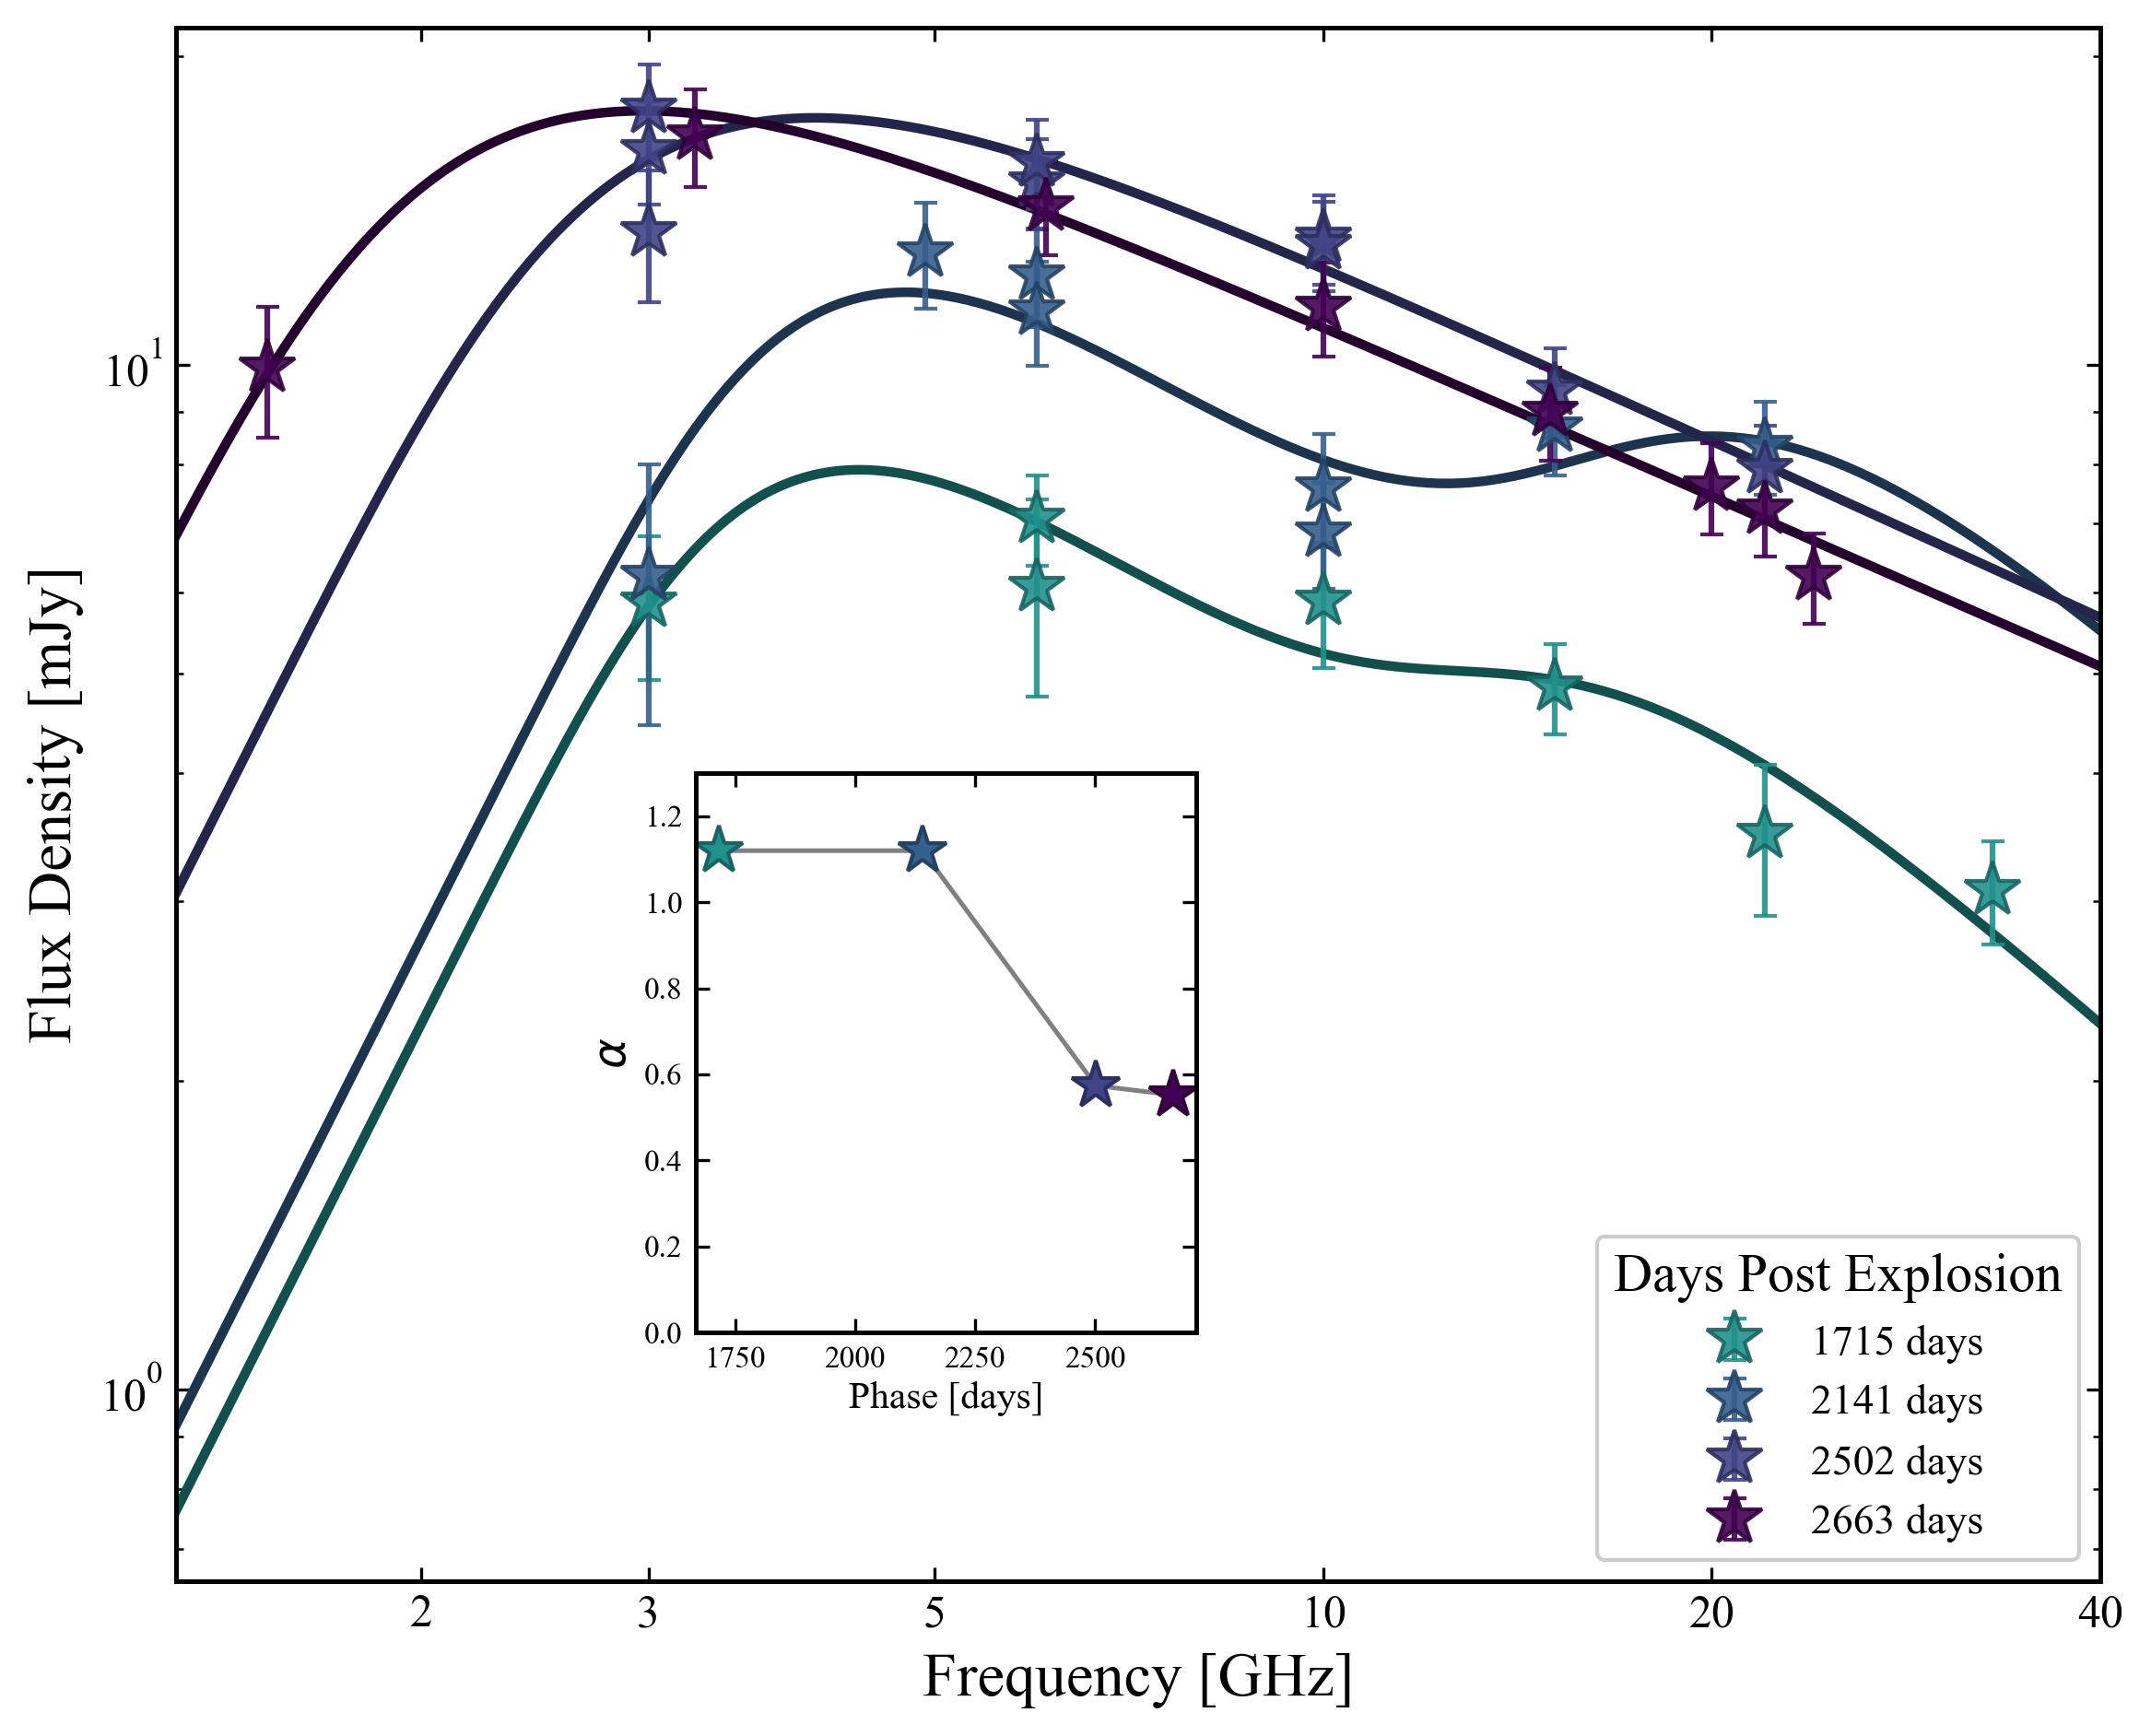

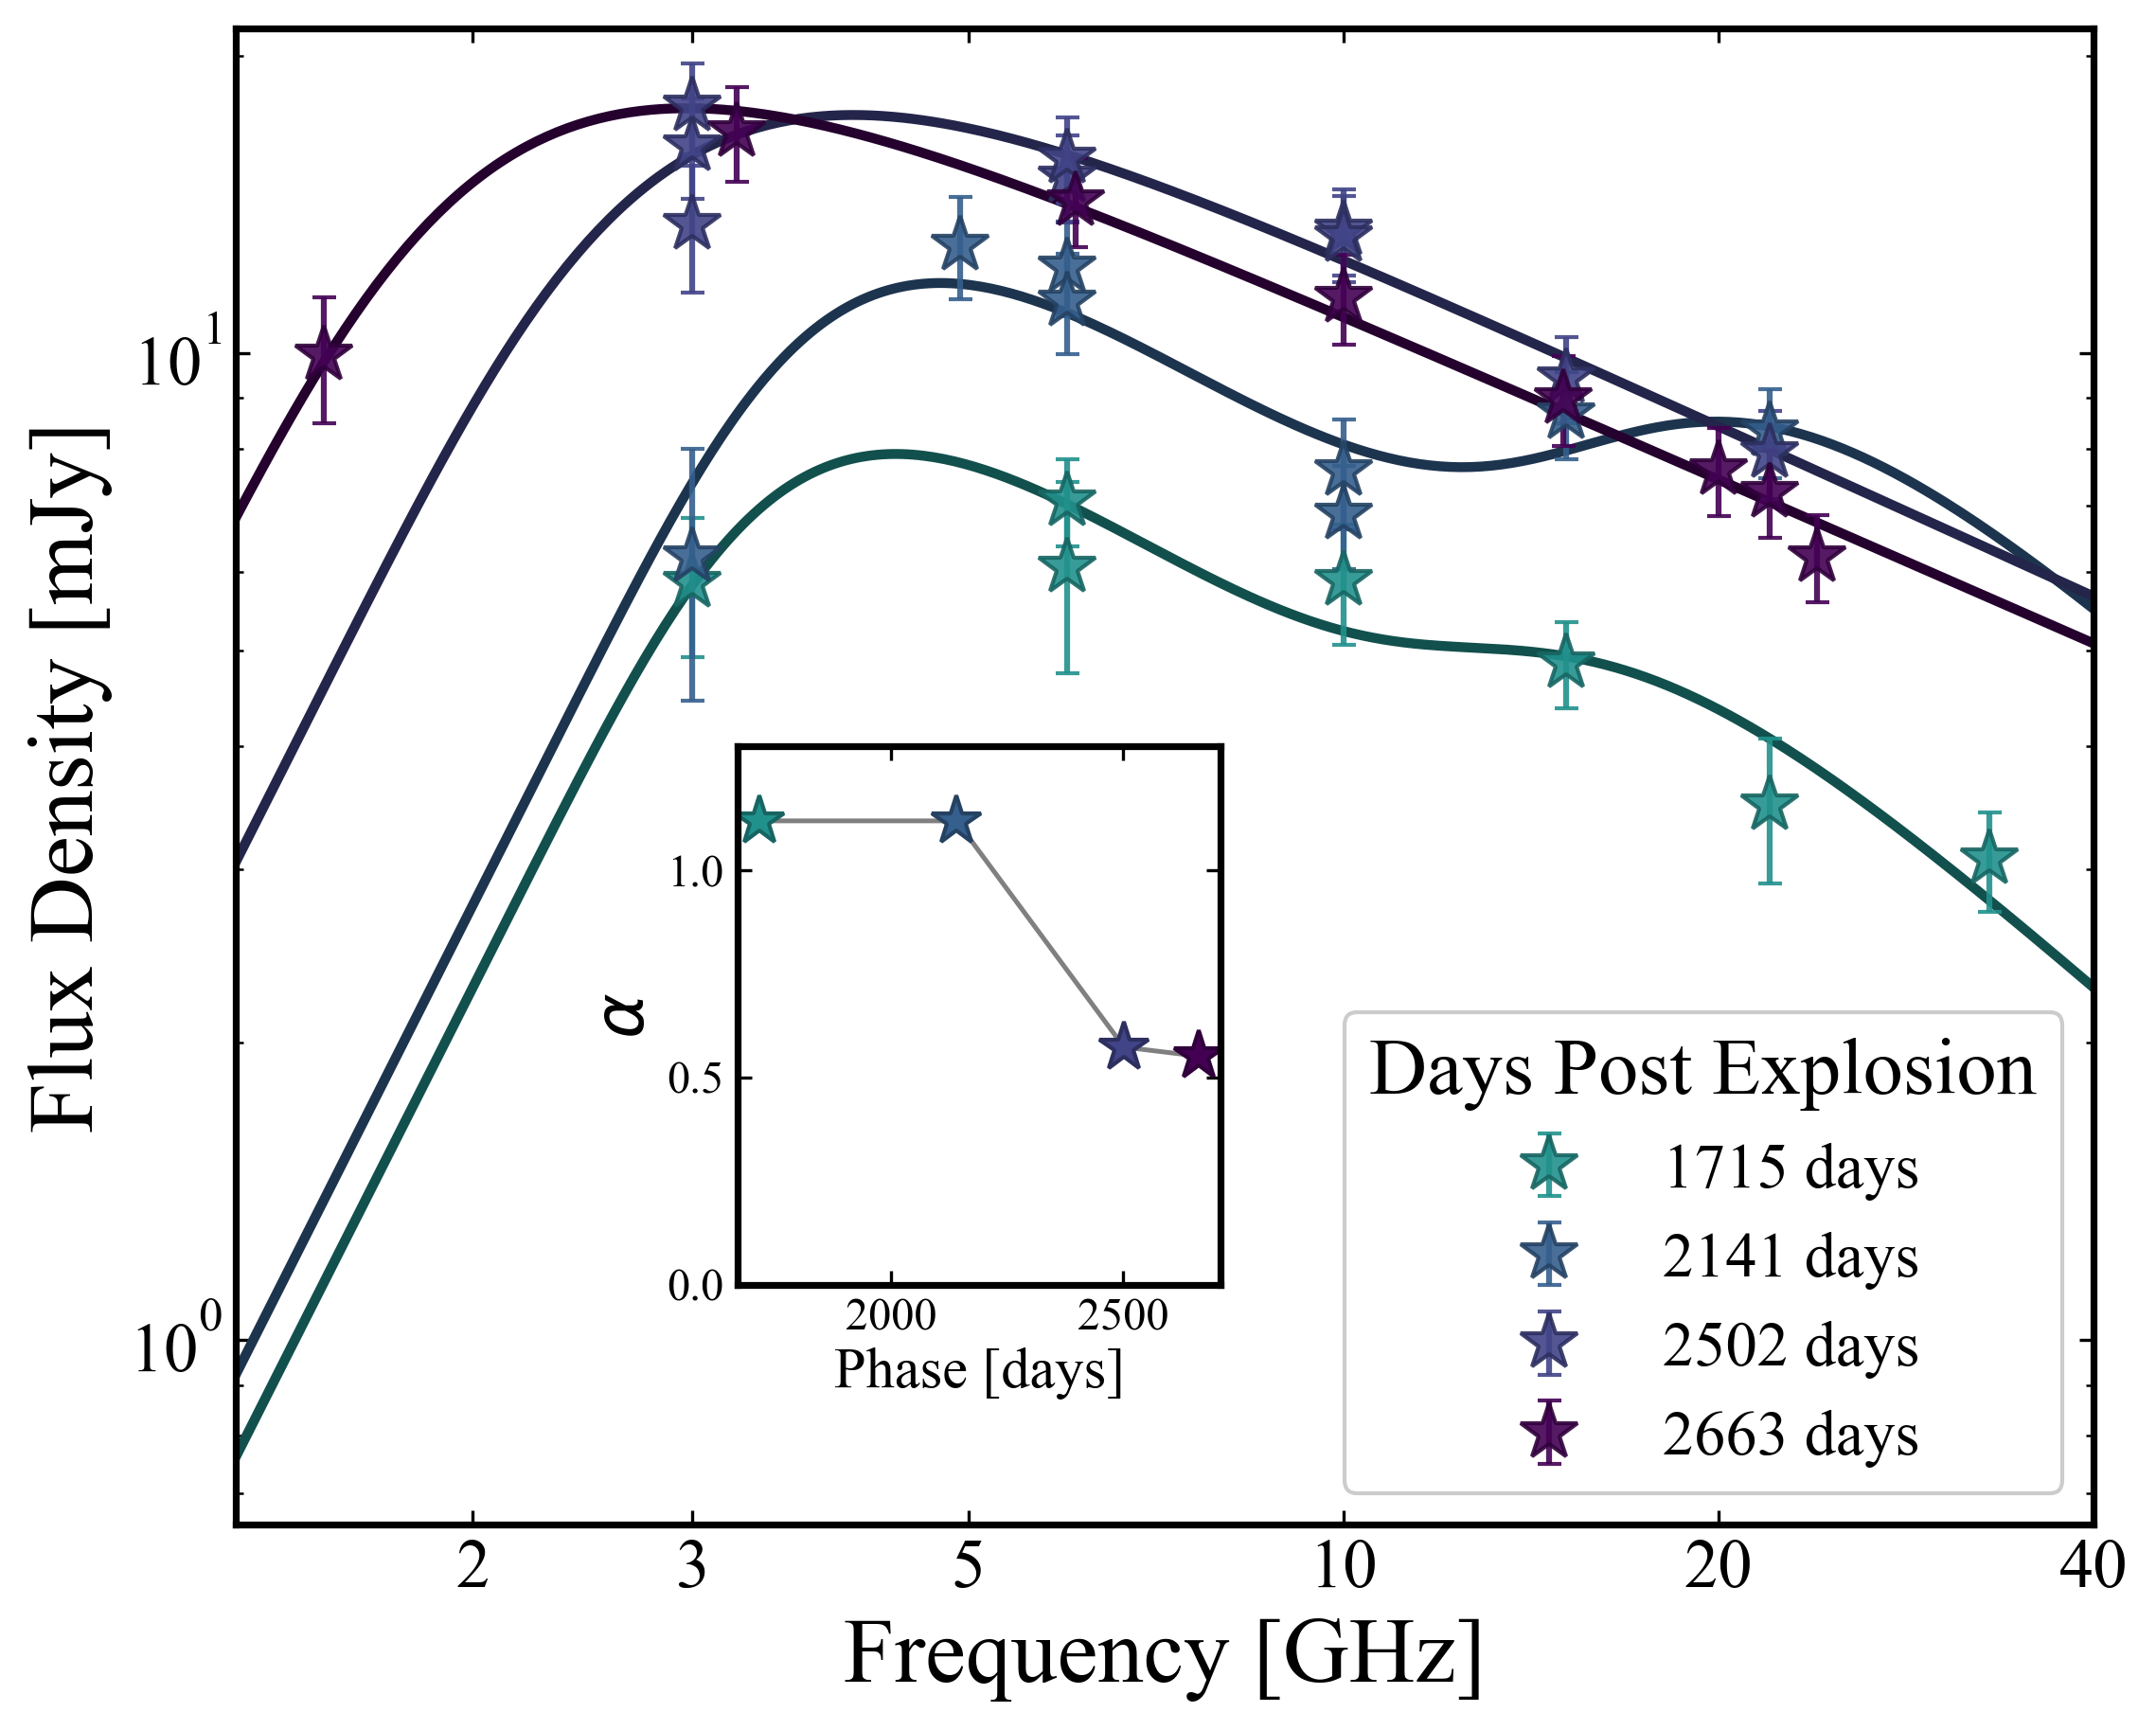

In [4]:
# Standard (paper-style) rendering -- unchanged filenames.
build_sed_figure(scale=1.0, suffix="")
plt.show()

# Proposal rendering -- larger fonts throughout (JWST proposal figures are
# typically embedded smaller than a paper figure, so text needs to start
# bigger to stay legible). Separate files, doesn't touch the standard ones.
build_sed_figure(scale=1.45, suffix="_proposal")
plt.show()